<div style="background-color: #f8f9fa; padding: 20px; border-radius: 10px; box-shadow: 0 4px 6px rgba(0, 0, 0, 0.1);">
  <div style="display: flex; justify-content: space-between; align-items: center;">
    <img src="https://raw.githubusercontent.com/carlosfab/blog-sigmoidal/main/_assets/logo_sigmoidal.png" alt="Sigmoidal" style="height: 60px;">
    <div style="text-align: right;">
      <p style="margin: 0; font-size: 14px; color: #6c757d;"><strong>Carlos Melo</strong> · Sigmoidal</p>
      <p style="margin: 0; font-size: 12px; color: #6c757d;">Cientista de Dados · Visão Computacional</p>
    </div>
  </div>
</div>

# Imputação de Dados Ausentes com Scikit-Learn

Material de apoio do artigo [Imputação de Dados Ausentes com Scikit-Learn](https://sigmoidal.ai) no blog da Sigmoidal.

Neste notebook, você vai comparar quatro estratégias de imputação (média, mediana, KNN e imputação iterativa) em um cenário controlado, no qual conhecemos os valores verdadeiros que foram removidos. Isso permite medir o erro de reconstrução de cada método e, em seguida, o impacto de cada estratégia no desempenho do modelo final.

> O notebook roda de ponta a ponta no Google Colab gratuito, sem GPU.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

sns.set_theme(style="whitegrid", palette="deep")

## 1. Um cenário controlado

O dataset California Housing não possui valores ausentes. É exatamente por isso que ele serve ao experimento: nós mesmos removemos uma fração dos valores, guardando o gabarito, e assim podemos comparar o que cada imputador reconstrói contra o valor verdadeiro.

Para manter o experimento leve, trabalhamos com uma amostra de 5.000 distritos.

In [2]:
# Carrega o dataset e extrai uma amostra reproduzível de 5.000 linhas
dados = fetch_california_housing(as_frame=True)
df_completo = dados.frame.sample(n=5000, random_state=RANDOM_STATE).reset_index(drop=True)

X_completo = df_completo.drop(columns="MedHouseVal")
y = df_completo["MedHouseVal"]

X_completo.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,3.85,28.74,5.42,1.10,1424.91,2.96,35.59,-119.52
std,1.89,12.53,2.65,0.57,1108.47,1.64,2.14,2.01
min,0.50,1.00,0.85,0.50,8.00,1.26,32.54,-124.25
25%,2.55,18.00,4.42,1.00,784.00,2.43,33.93,-121.74
50%,3.51,29.00,5.22,1.05,1163.50,2.82,34.22,-118.47
75%,4.70,37.00,6.04,1.10,1721.25,3.29,37.69,-117.99
max,15.00,52.00,132.53,34.07,16122.00,83.17,41.86,-114.58


### Injetando a ausência

Removemos valores segundo dois mecanismos clássicos da literatura:

- **MCAR** (*Missing Completely At Random*): 15% dos valores de `MedInc` são removidos de forma puramente aleatória;
- **MAR** (*Missing At Random*): a probabilidade de `AveRooms` estar ausente cresce com a idade do imóvel (`HouseAge`), ou seja, a ausência depende de outra variável observada.

In [3]:
X = X_completo.copy()

# MCAR: 15% dos valores de MedInc removidos ao acaso
mascara_mcar = rng.random(len(X)) < 0.15
X.loc[mascara_mcar, "MedInc"] = np.nan

# MAR: probabilidade de ausência em AveRooms cresce com HouseAge
# (varia de ~5% nos imóveis mais novos a ~35% nos mais antigos)
idade = X["HouseAge"]
prob_mar = 0.05 + 0.30 * (idade - idade.min()) / (idade.max() - idade.min())
mascara_mar = rng.random(len(X)) < prob_mar
X.loc[mascara_mar, "AveRooms"] = np.nan

X.isnull().sum()

MedInc         752
HouseAge         0
AveRooms      1068
AveBedrms        0
Population       0
AveOccup         0
Latitude         0
Longitude        0
dtype: int64

## 2. Diagnóstico da ausência

Antes de imputar, é preciso entender o padrão da ausência. O primeiro gráfico mostra a proporção de valores ausentes por coluna; o segundo revela o mecanismo MAR: a fração de `AveRooms` ausente cresce de forma consistente com a idade do imóvel.

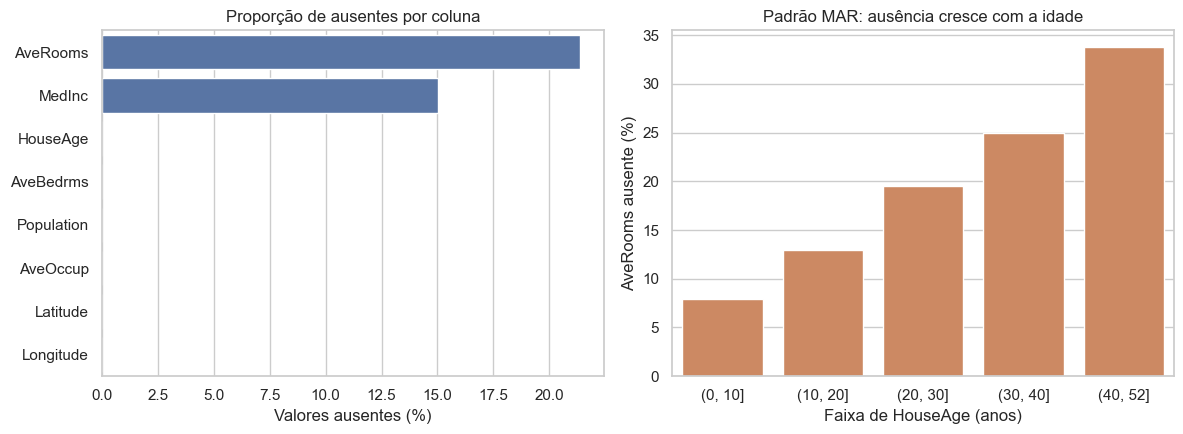

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Proporção de ausentes por coluna
prop_ausentes = (X.isnull().mean() * 100).sort_values(ascending=False)
sns.barplot(x=prop_ausentes.values, y=prop_ausentes.index, ax=ax1, color="#4C72B0")
ax1.set_xlabel("Valores ausentes (%)")
ax1.set_ylabel("")
ax1.set_title("Proporção de ausentes por coluna")

# Fração de AveRooms ausente por faixa de idade do imóvel
faixas = pd.cut(X["HouseAge"], bins=[0, 10, 20, 30, 40, 52])
frac_por_faixa = X["AveRooms"].isnull().groupby(faixas, observed=True).mean() * 100
sns.barplot(x=frac_por_faixa.index.astype(str), y=frac_por_faixa.values, ax=ax2, color="#DD8452")
ax2.set_xlabel("Faixa de HouseAge (anos)")
ax2.set_ylabel("AveRooms ausente (%)")
ax2.set_title("Padrão MAR: ausência cresce com a idade")

plt.tight_layout()
plt.show()

## 3. O efeito da imputação na distribuição

A imputação pela média é a mais usada na prática, mas ela concentra todos os valores imputados em um único ponto. O gráfico compara a distribuição verdadeira de `MedInc` com a distribuição após a imputação pela média e após a imputação por KNN.

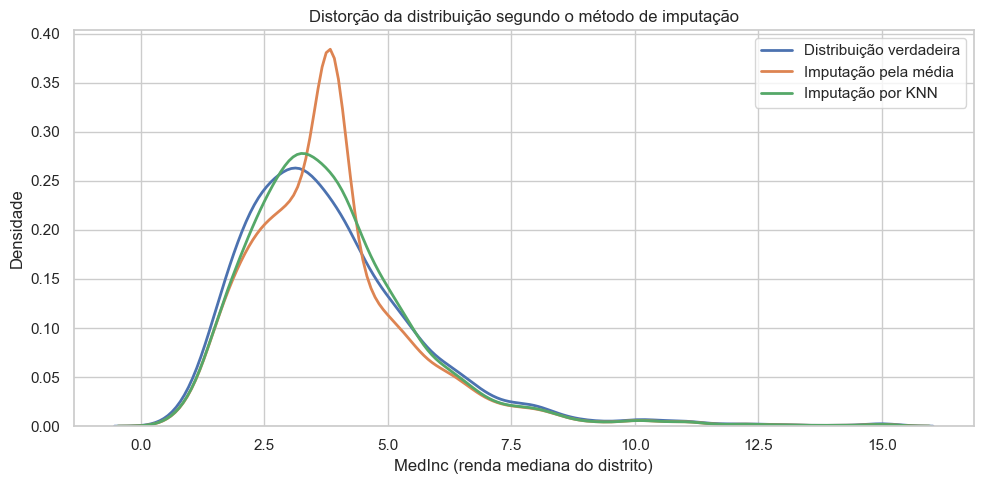

In [5]:
# Imputa MedInc pela média e por KNN para comparar as distribuições
imp_media = SimpleImputer(strategy="mean")
medinc_media = imp_media.fit_transform(X)[:, X.columns.get_loc("MedInc")]

imp_knn = KNNImputer(n_neighbors=5)
medinc_knn = imp_knn.fit_transform(X)[:, X.columns.get_loc("MedInc")]

fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(X_completo["MedInc"], ax=ax, label="Distribuição verdadeira", linewidth=2)
sns.kdeplot(medinc_media, ax=ax, label="Imputação pela média", linewidth=2)
sns.kdeplot(medinc_knn, ax=ax, label="Imputação por KNN", linewidth=2)
ax.set_xlabel("MedInc (renda mediana do distrito)")
ax.set_ylabel("Densidade")
ax.set_title("Distorção da distribuição segundo o método de imputação")
ax.legend()
plt.tight_layout()
plt.show()

O pico artificial na média é a assinatura da imputação simples: a variância da coluna diminui e as correlações com as demais variáveis são atenuadas. O KNN, por usar os vizinhos mais próximos no espaço de atributos, preserva melhor o formato da distribuição original.

## 4. Erro de reconstrução: comparando contra o gabarito

Como guardamos os valores verdadeiros, podemos medir a raiz do erro quadrático médio (RMSE) entre o valor imputado e o valor real, apenas nas posições que foram mascaradas.

In [6]:
imputadores = {
    "Média": SimpleImputer(strategy="mean"),
    "Mediana": SimpleImputer(strategy="median"),
    "KNN (k=5)": KNNImputer(n_neighbors=5),
    "Iterativa": IterativeImputer(max_iter=10, random_state=RANDOM_STATE),
}

registros = []
for nome, imputador in imputadores.items():
    X_imputado = pd.DataFrame(imputador.fit_transform(X), columns=X.columns)
    for coluna, mascara in [("MedInc", mascara_mcar), ("AveRooms", mascara_mar)]:
        verdadeiro = X_completo.loc[mascara, coluna]
        imputado = X_imputado.loc[mascara, coluna]
        rmse = np.sqrt(np.mean((verdadeiro - imputado) ** 2))
        registros.append({"Imputador": nome, "Coluna": coluna, "RMSE": rmse})

resultado_rmse = pd.DataFrame(registros)
resultado_rmse.pivot(index="Imputador", columns="Coluna", values="RMSE").round(3)

Coluna,AveRooms,MedInc
Imputador,,
Iterativa,0.855,1.326
KNN (k=5),1.662,2.021
Mediana,1.573,1.928
Média,1.584,1.897


O resultado da imputação iterativa se destaca, mas o KNN apresenta um comportamento inesperado: ele perde até para a média. A explicação está na métrica de distância. O `KNNImputer` calcula distâncias euclidianas sobre as colunas em suas escalas originais, e `Population`, com desvio padrão na casa dos milhares, domina completamente o cálculo. Os vizinhos escolhidos acabam sendo os distritos de população parecida, e não os distritos de fato semelhantes.

A correção é padronizar as colunas antes de imputar e retornar à escala original em seguida.

In [7]:
from sklearn.preprocessing import StandardScaler

# KNN com padronização prévia: escala, imputa e desfaz a escala
escala = StandardScaler()
X_escalado = escala.fit_transform(X)
imputado_escalado = KNNImputer(n_neighbors=5).fit_transform(X_escalado)
X_knn_escala = pd.DataFrame(escala.inverse_transform(imputado_escalado), columns=X.columns)

for coluna, mascara in [("MedInc", mascara_mcar), ("AveRooms", mascara_mar)]:
    verdadeiro = X_completo.loc[mascara, coluna]
    imputado = X_knn_escala.loc[mascara, coluna]
    rmse = np.sqrt(np.mean((verdadeiro - imputado) ** 2))
    registros.append({"Imputador": "KNN + escala", "Coluna": coluna, "RMSE": rmse})

resultado_rmse = pd.DataFrame(registros)
resultado_rmse.pivot(index="Imputador", columns="Coluna", values="RMSE").round(3)

Coluna,AveRooms,MedInc
Imputador,,
Iterativa,0.855,1.326
KNN (k=5),1.662,2.021
KNN + escala,1.004,1.522
Mediana,1.573,1.928
Média,1.584,1.897


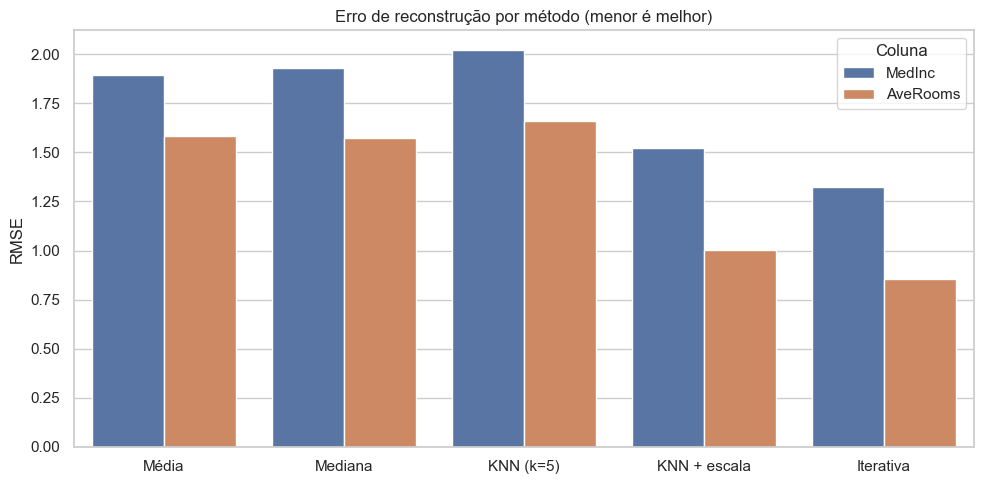

In [8]:
ordem = ["Média", "Mediana", "KNN (k=5)", "KNN + escala", "Iterativa"]

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=resultado_rmse, x="Imputador", y="RMSE", hue="Coluna", order=ordem, ax=ax)
ax.set_title("Erro de reconstrução por método (menor é melhor)")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

## 5. Impacto no modelo final

O erro de reconstrução conta apenas metade da história. O que importa em um projeto real é o desempenho do modelo treinado sobre os dados imputados. Avaliamos cinco estratégias com validação cruzada de 5 folds, usando um Random Forest como regressor. A estratégia de descarte (*listwise deletion*) remove todas as linhas com pelo menos um valor ausente.

In [9]:
modelo = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)

desempenho = {}

# Estratégia 1: descartar linhas com valores ausentes
completos = X.dropna()
scores_drop = cross_val_score(
    modelo, completos, y.loc[completos.index],
    cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1
)
desempenho["Descarte"] = -scores_drop
print(f"Descarte: {len(completos)} de {len(X)} linhas restantes")

# Demais estratégias: imputação dentro de um pipeline (sem vazamento entre folds)
pipelines = {
    "Média": Pipeline([("imputacao", SimpleImputer(strategy="mean")), ("modelo", modelo)]),
    "Mediana": Pipeline([("imputacao", SimpleImputer(strategy="median")), ("modelo", modelo)]),
    "KNN + escala": Pipeline([
        ("escala", StandardScaler()),
        ("imputacao", KNNImputer(n_neighbors=5)),
        ("modelo", modelo),
    ]),
    "Iterativa": Pipeline([
        ("imputacao", IterativeImputer(max_iter=10, random_state=RANDOM_STATE)),
        ("modelo", modelo),
    ]),
}
for nome, pipe in pipelines.items():
    scores = cross_val_score(
        pipe, X, y, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1
    )
    desempenho[nome] = -scores

resultado_modelo = pd.DataFrame(desempenho)
resultado_modelo.agg(["mean", "std"]).round(4)

Descarte: 3347 de 5000 linhas restantes


,Descarte,Média,Mediana,KNN + escala,Iterativa
mean,0.5866,0.5732,0.5723,0.5989,0.5923
std,0.0314,0.0242,0.0243,0.0225,0.0252


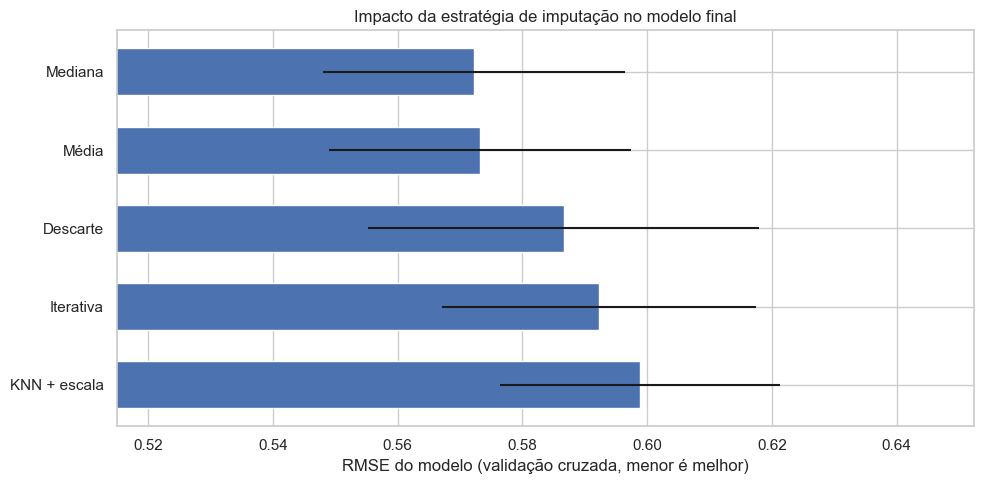

In [10]:
medias = resultado_modelo.mean().sort_values(ascending=False)
desvios = resultado_modelo.std()[medias.index]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(medias.index, medias.values, xerr=desvios.values, color="#4C72B0", height=0.6)
ax.set_xlabel("RMSE do modelo (validação cruzada, menor é melhor)")
ax.set_title("Impacto da estratégia de imputação no modelo final")
ax.set_xlim(left=medias.min() * 0.9)
plt.tight_layout()
plt.show()

## Conclusão

- A imputação pela média distorce a distribuição da variável e atenua correlações; o efeito é visível na densidade de `MedInc`.
- No erro de reconstrução, a imputação iterativa supera os demais métodos; o KNN só se torna competitivo depois da padronização das colunas, porque a distância euclidiana é dominada pelas variáveis de maior escala.
- No desempenho do modelo final, as diferenças entre os métodos de imputação são pequenas, e o erro de reconstrução não se traduz de forma direta em ganho no modelo.
- A imputação deve sempre ocorrer dentro de um `Pipeline`, para que as estatísticas sejam aprendidas apenas no conjunto de treino de cada fold.

O artigo completo, com a interpretação de cada resultado, está no [blog da Sigmoidal](https://sigmoidal.ai).